# Milos — farmer WSP + replan Gantt

Self-contained under `milos/` (no `agent/`). Primary plots are **farmer-only** (5 tiles).

Optional: smoke `[wsp_plan]` lines from the live agent are filtered to zone I (`t1`–`t5`) so you can compare day-0 / replan for the farmer snake only — not full TwoLand.


In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "main.py").exists() and not (ROOT / "milos").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

%matplotlib inline

from milos.wsp import load_wsp_plans, plot_plan, solve, FARMER_TILES_FIVE

SMOKE_LOG = ROOT / "scripts/smoke.txt"
print(SMOKE_LOG, SMOKE_LOG.exists())


/media/wlaki/W/DS_projects/Kaggle/kaggriculture/scripts/smoke.txt True


## Farmer-only WSP (`milos.wsp.solve`)

Day-0 uses `milos/wsp/prestart.json` when horizon=30 and all 5 tiles empty; otherwise runs the local MIP.


[milos/wsp] farmer prestart loaded tiles=5 from prestart.json complete=True
complete True tiles [0, 1, 2, 3, 4]


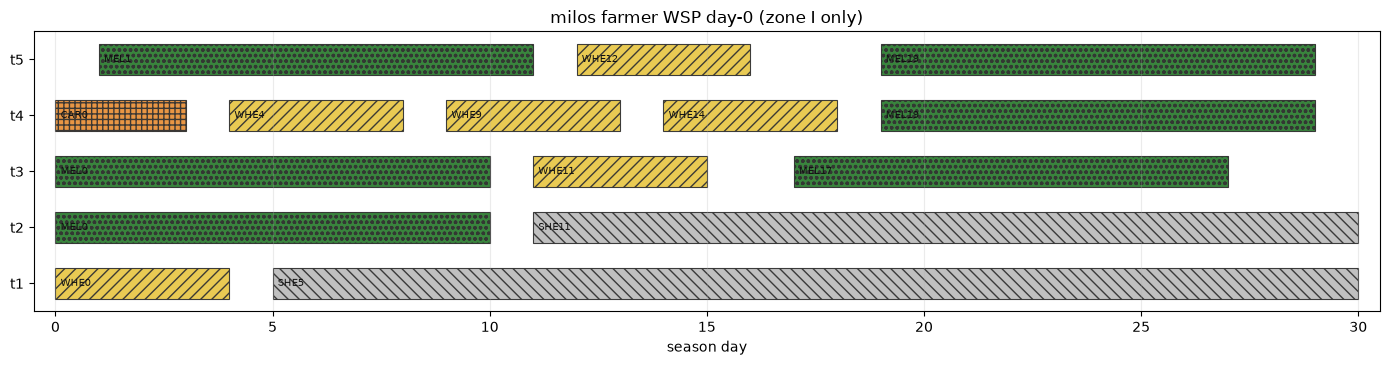

In [11]:
from milos.wsp import data as wsp_data

i0 = wsp_data.i0_base_prices()
price_of = lambda p, _i0=i0: _i0[p]

empty = list(FARMER_TILES_FIVE)
result = solve(
    [],
    horizon=30,
    empty_tiles=empty,
    empty_counts={"farmer": len(empty)},
    starting_money=3000,
    price_of=price_of,
)
print("complete", result.complete, "tiles", sorted(result.assigned))
plot_plan(
    result.assigned,
    replan_day=0,
    horizon=30,
    title="milos farmer WSP day-0 (zone I only)",
)


## Smoke log — farmer zone only

Live smoke still runs `twoland_wsp`, so `[wsp_plan]` payloads include land-1. Here we **keep only** `FARMER_TILES_FIVE` before plotting.

Requires `bash scripts/smoke_test.sh` (`KAGGRI_VERBOSE=1`).


23 [wsp_plan] events (plotting farmer tiles [0, 1, 2, 3, 4] only)


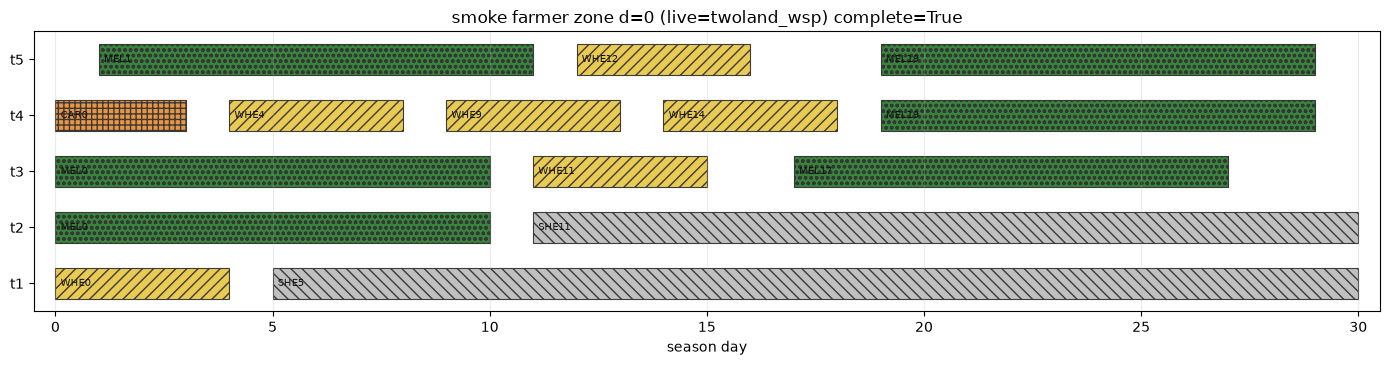

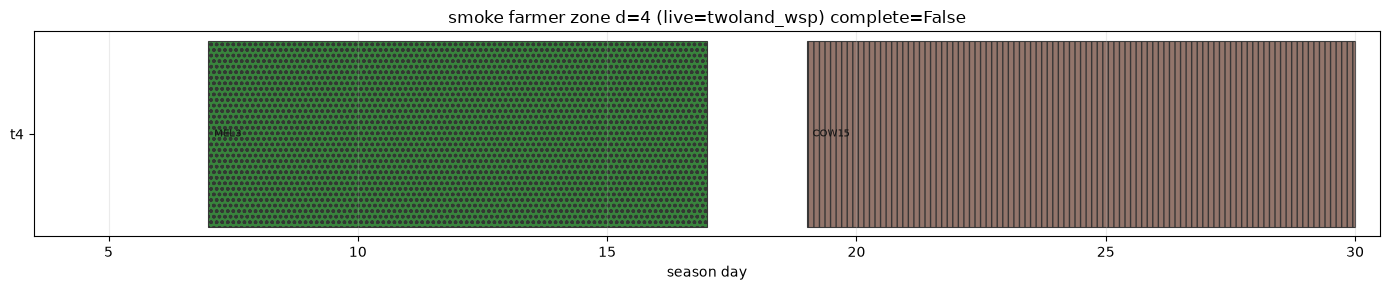

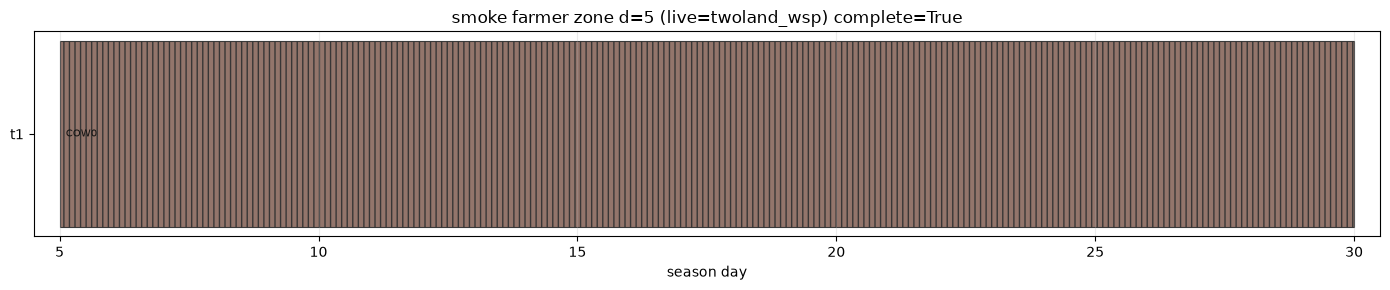

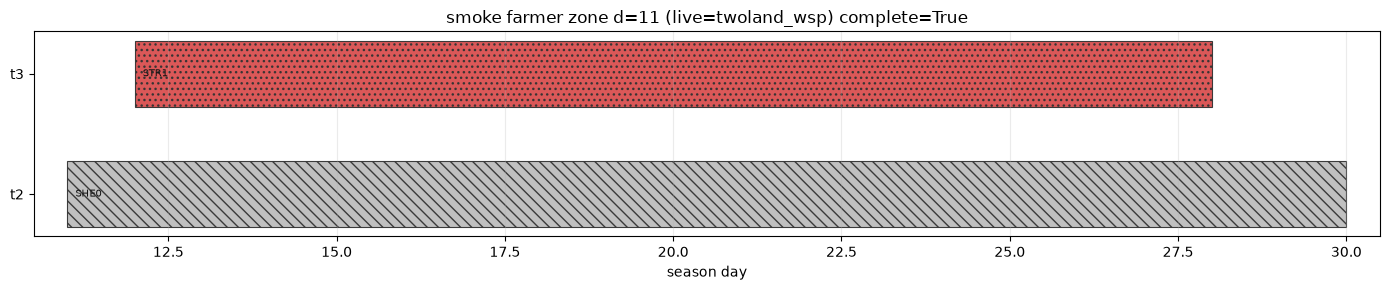

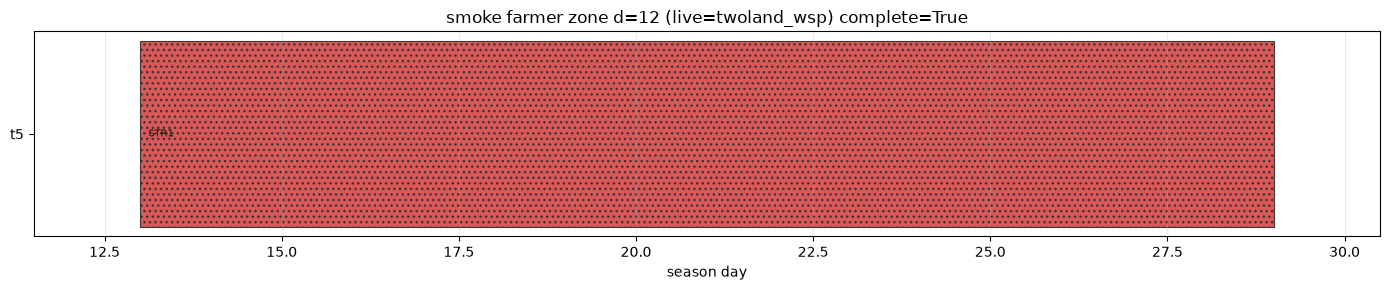

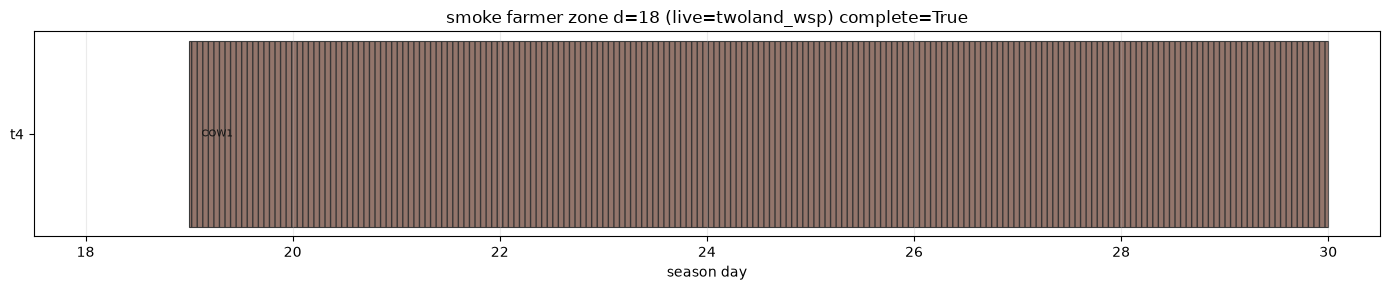

In [12]:
farmer_set = set(FARMER_TILES_FIVE)
plans = load_wsp_plans(SMOKE_LOG) if SMOKE_LOG.exists() else []
print(f"{len(plans)} [wsp_plan] events (plotting farmer tiles {sorted(farmer_set)} only)")
for p in plans:
    assigned = {t: chain for t, chain in p.assigned.items() if t in farmer_set}
    if not assigned:
        continue
    plot_plan(
        assigned,
        replan_day=p.day,
        horizon=p.horizon,
        title=f"smoke farmer zone d={p.day} (live={p.solver}) complete={p.complete}",
    )
